
# This notebook will:

load the raw county NRI file

load the NRI data dictionary

search for safe general predictors

merge them with your cleaned wildfire target table

save a baseline modeling file

# **Cell 1 — Imports**

In [1]:
import pandas as pd
import numpy as np
import re

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 150)


# **Cell 2 — Paths**

In [2]:
RAW_NRI_PATH = "/content/NRI_Table_Counties.csv"
DICT_PATH = "/content/NRIDataDictionary.csv"
TARGET_PATH = "/content/nri_wildfire_county_target.csv"


# **Cell 3 — Load files**

In [3]:
raw_df = pd.read_csv(RAW_NRI_PATH, low_memory=False)
dict_df = pd.read_csv(DICT_PATH, low_memory=False)
target_df = pd.read_csv(TARGET_PATH, dtype={"county_fips": str})

target_df["county_fips"] = target_df["county_fips"].str.zfill(5)

print("Raw NRI shape:", raw_df.shape)
print("Dictionary shape:", dict_df.shape)
print("Target shape:", target_df.shape)

print("\nRaw NRI head:")
display(raw_df.head())

print("\nDictionary head:")
display(dict_df.head())

print("\nTarget head:")
display(target_df.head())


Raw NRI shape: (3232, 465)
Dictionary shape: (479, 9)
Target shape: (3144, 14)

Raw NRI head:


,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,POPULATION,BUILDVALUE,AGRIVALUE,AREA,RISK_VALUE,RISK_SCORE,RISK_RATNG,RISK_SPCTL,EAL_SCORE,EAL_RATNG,EAL_SPCTL,EAL_VALT,EAL_VALB,EAL_VALP,EAL_VALPE,EAL_VALA,ALR_VALB,ALR_VALP,ALR_VALA,ALR_NPCTL,ALR_VRA_NPCTL,SOVI_SCORE,SOVI_RATNG,SOVI_SPCTL,RESL_SCORE,RESL_RATNG,RESL_SPCTL,RESL_VALUE,CRF_VALUE,AVLN_EVNTS,AVLN_AFREQ,AVLN_EXP_AREA,AVLN_EXPB,AVLN_EXPP,AVLN_EXPPE,AVLN_EXPT,AVLN_HLRB,AVLN_HLRP,AVLN_HLRR,AVLN_EALB,AVLN_EALP,AVLN_EALPE,AVLN_EALT,AVLN_EALS,AVLN_EALR,AVLN_ALRB,AVLN_ALRP,AVLN_ALR_NPCTL,AVLN_RISKV,AVLN_RISKS,AVLN_RISKR,CFLD_EVNTS,CFLD_AFREQ,CFLD_EXP_AREA,CFLD_EXPB,CFLD_EXPP,CFLD_EXPPE,CFLD_EXPT,CFLD_HLRB,CFLD_HLRP,CFLD_HLRR,CFLD_EALB,CFLD_EALP,CFLD_EALPE,CFLD_EALT,CFLD_EALS,CFLD_EALR,CFLD_ALRB,CFLD_ALRP,CFLD_ALR_NPCTL,CFLD_RISKV,CFLD_RISKS,CFLD_RISKR,CWAV_EVNTS,CWAV_AFREQ,CWAV_EXP_AREA,CWAV_EXPB,CWAV_EXPP,CWAV_EXPPE,CWAV_EXPA,CWAV_EXPT,CWAV_HLRB,CWAV_HLRP,CWAV_HLRA,CWAV_HLRR,CWAV_EALB,CWAV_EALP,CWAV_EALPE,CWAV_EALA,CWAV_EALT,CWAV_EALS,...,TRND_RISKV,TRND_RISKS,TRND_RISKR,TSUN_EVNTS,TSUN_AFREQ,TSUN_EXP_AREA,TSUN_EXPB,TSUN_EXPP,TSUN_EXPPE,TSUN_EXPT,TSUN_HLRB,TSUN_HLRP,TSUN_HLRR,TSUN_EALB,TSUN_EALP,TSUN_EALPE,TSUN_EALT,TSUN_EALS,TSUN_EALR,TSUN_ALRB,TSUN_ALRP,TSUN_ALR_NPCTL,TSUN_RISKV,TSUN_RISKS,TSUN_RISKR,VLCN_EVNTS,VLCN_AFREQ,VLCN_EXP_AREA,VLCN_EXPB,VLCN_EXPP,VLCN_EXPPE,VLCN_EXPT,VLCN_HLRB,VLCN_HLRP,VLCN_HLRR,VLCN_EALB,VLCN_EALP,VLCN_EALPE,VLCN_EALT,VLCN_EALS,VLCN_EALR,VLCN_ALRB,VLCN_ALRP,VLCN_ALR_NPCTL,VLCN_RISKV,VLCN_RISKS,VLCN_RISKR,WFIR_EVNTS,WFIR_AFREQ,WFIR_EXP_AREA,WFIR_EXPB,WFIR_EXPP,WFIR_EXPPE,WFIR_EXPA,WFIR_EXPT,WFIR_HLRB,WFIR_HLRP,WFIR_HLRA,WFIR_HLRR,WFIR_EALB,WFIR_EALP,WFIR_EALPE,WFIR_EALA,WFIR_EALT,WFIR_EALS,WFIR_EALR,WFIR_ALRB,WFIR_ALRP,WFIR_ALRA,WFIR_ALR_NPCTL,WFIR_RISKV,WFIR_RISKS,WFIR_RISKR,WNTW_EVNTS,WNTW_AFREQ,WNTW_EXP_AREA,WNTW_EXPB,WNTW_EXPP,WNTW_EXPPE,WNTW_EXPA,WNTW_EXPT,WNTW_HLRB,WNTW_HLRP,WNTW_HLRA,WNTW_HLRR,WNTW_EALB,WNTW_EALP,WNTW_EALPE,WNTW_EALA,WNTW_EALT,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
0,1,C01001,Alabama,AL,1,Autauga,County,1,1001,58764,1.024141e+10,27630646.0,610.470508,2.051090e+07,57.569975,Relatively Low,57.569975,59.870050,Relatively Low,56.716418,1.975657e+07,1.385350e+07,0.412821,5.655652e+06,2.474187e+05,0.001518,0.000007,0.010052,49.721535,45.515267,38.040712,Relatively Low,9.701493,55.120865,Relatively Moderate,76.119403,2.494860,1.038181,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,7.000000,0.368421,610.470508,1.024141e+10,58764.0,8.050668e+11,27630646.0,8.153358e+11,8.092943e-07,1.205327e-07,0.001287,Relatively Low,3053.588720,0.026571,3.640163e+05,13096.648973,3.801666e+05,31.219059,...,3.112728e+06,74.109415,Relatively Moderate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,0.000569,23.109638,1.367163e+09,10559.815261,1.446695e+11,4.004713e+06,1.460406e+11,0.1,0.000117,0.007141,Very Low,3.002976e+04,0.000454,6216.075404,16.406169,3.626224e+04,47.105598,Very Low,0.000003,7.721192e-09,5.937671e-07,41.348601,3.764677e+04,45.737913,Very Low,26.00000,1.368421,610.470508,1.024141e+10,58764.0,8.050668e+11,27630646.0,8.153358e+11,1.606919e-07,3.977501e-09,1.040342e-06,Very Low,2252.026376,0.000320,4381.894510,39.336299,6673.257184,13.095975,Very Low,2.198943e-07,5.442896e-09,1.423647e-06,27.739938,6928.050098,9.038829,Very Low,December 2025
1,2,C01003,Alabama,AL,1,Baldwin,County,3,1003,231365,5.160230e+10,155012958.0,2047.738775,2.532687e+08,96.723919,Relatively High,96.723919,96.627475,Relatively High,97.014925,2.373912e+08,2.084471e+08,1.932259,2.6471


Dictionary head:


,Sort,Field Name,Field Alias,Type,Length,Relevant Layer,Metric Type,Version,Version Date
0,1,OBJECTID,OBJECTID,Integer,4.0,NaN,NaN,1.20.0,December 2025
1,2,Shape,Shape,Geometry,NaN,NaN,NaN,1.20.0,December 2025
2,3,Shape_Length,Shape_Length,Double,8.0,NaN,NaN,1.20.0,December 2025
3,4,Shape_Area,Shape_Area,Double,8.0,NaN,NaN,1.20.0,December 2025
4,5,STATE,State Name,String,250.0,All,NaN,1.20.0,December 2025



Target head:


,state,county,county_fips,wildfire_eal,wildfire_risk_score,wildfire_risk_rating,wildfire_annual_frequency,wildfire_eal_buildings,wildfire_eal_population,wildfire_eal_agriculture,wildfire_eal_score_like,wildfire_eal_rating_like,wildfire_risk_value,log_wildfire_eal
0,Alabama,Autauga,01001,3.626224e+04,45.737913,Very Low,0.000569,3.002976e+04,0.000454,16.406169,47.105598,Very Low,3.764677e+04,10.498560
1,Alabama,Baldwin,01003,1.500314e+06,90.776081,Relatively Moderate,0.003136,1.282742e+06,0.015847,470.262851,91.125954,Relatively Moderate,1.600660e+06,14.221186
2,Alabama,Barbour,01005,2.590932e+04,48.854962,Very Low,0.000688,2.161196e+04,0.000303,150.438881,41.666667,Very Low,4.644979e+04,10.162397
3,Alabama,Bibb,01007,3.260612e+04,48.664122,Very Low,0.000999,2.579498e+04,0.000497,8.942955,45.451654,Very Low,4.594325e+04,10.392286
4,Alabama,Blount,01009,9.336726e+04,65.044529,Relatively Low,0.001551,7.351167e+04,0.001407,581.805384,62.468193,Relatively Low,1.258597e+05,11.444307


# **Cell 4 — Inspect dictionary columns**

In [4]:
print("Dictionary columns:")
for c in dict_df.columns:
    print(c)


Dictionary columns:
Sort
Field Name
Field Alias
Type
Length
Relevant Layer
Metric Type
Version
Version Date


# **Cell 5 — Search the dictionary for useful generic predictors**

In [5]:
keywords = [
    "population", "building", "value", "agriculture", "area",
    "social vulnerability", "resilience", "housing", "income",
    "poverty", "forest", "land", "community"
]

pattern = "|".join([re.escape(k) for k in keywords])

matches = dict_df[
    dict_df.apply(
        lambda row: row.astype(str).str.contains(pattern, case=False, na=False).any(),
        axis=1
    )
].copy()

print("Possible useful dictionary matches:")
display(matches)


Possible useful dictionary matches:


,Sort,Field Name,Field Alias,Type,Length,Relevant Layer,Metric Type,Version,Version Date
3,4,Shape_Area,Shape_Area,Double,8.0,NaN,NaN,1.20.0,December 2025
14,15,POPULATION,Population (2020),Integer,4.0,All,NaN,1.20.0,December 2025
15,16,BUILDVALUE,Building Value ($),Double,8.0,All,NaN,1.20.0,December 2025
16,17,AGRIVALUE,Agriculture Value ($),Double,8.0,All,NaN,1.20.0,December 2025
17,18,AREA,Area (sq mi),Double,8.0,All,NaN,1.20.0,December 2025
...,...,...,...,...,...,...,...,...,...
474,475,JURS_AREA,FEMA Mitigation Planning Jurisdiction Layer - Tribal Area,String,254.0,All,NaN,1.20.0,December 2025
475,476,JURS_TYPE,FEMA Mitigation Planning Jurisdiction Layer - Tribal Area Type,String,254.0,All,NaN,1.20.0,December 2025
476,477,HIFLD_NAME,Homeland Infrastructure Foundation-Level Data (HIFLD) AIANNH Areas Dataset - Tribal Entity,String,100.0,All,NaN,1.20.0,December 2025
477,478,HIFLD_AREA,Homeland Infrastructure Foundation-Level Data (HIFLD) AIANNH Areas Dataset - Tribal Area,String,800.0,All,NaN,1.20.0,December 2025


# **Cell 6 — Search the raw county table for likely generic predictor columns**

In [6]:
generic_candidates = [
    c for c in raw_df.columns
    if re.search(
        r"(population|pop|building|build|value|agri|area|sovi|resl|resilience|vulnerability|housing|income|poverty|forest|land)",
        c,
        flags=re.IGNORECASE
    )
]

print("Likely generic predictor columns:")
for c in generic_candidates:
    print(c)


Likely generic predictor columns:
POPULATION
BUILDVALUE
AGRIVALUE
AREA
RISK_VALUE
SOVI_SCORE
SOVI_RATNG
SOVI_SPCTL
RESL_SCORE
RESL_RATNG
RESL_SPCTL
RESL_VALUE
CRF_VALUE
AVLN_EXP_AREA
CFLD_EXP_AREA
CWAV_EXP_AREA
DRGT_EXP_AREA
ERQK_EXP_AREA
HAIL_EXP_AREA
HWAV_EXP_AREA
HRCN_EXP_AREA
ISTM_EXP_AREA
LNDS_EXP_AREA
LTNG_EXP_AREA
IFLD_EXP_AREA
SWND_EXP_AREA
TRND_EXP_AREA
TSUN_EXP_AREA
VLCN_EXP_AREA
WFIR_EXP_AREA
WNTW_EXP_AREA


# **Cell 7 — Exclude wildfire-specific columns**

In [7]:
safe_generic_candidates = [
    c for c in generic_candidates
    if not c.startswith("WFIR_")
]

print("Likely safe non-wildfire candidates:")
for c in safe_generic_candidates:
    print(c)


Likely safe non-wildfire candidates:
POPULATION
BUILDVALUE
AGRIVALUE
AREA
RISK_VALUE
SOVI_SCORE
SOVI_RATNG
SOVI_SPCTL
RESL_SCORE
RESL_RATNG
RESL_SPCTL
RESL_VALUE
CRF_VALUE
AVLN_EXP_AREA
CFLD_EXP_AREA
CWAV_EXP_AREA
DRGT_EXP_AREA
ERQK_EXP_AREA
HAIL_EXP_AREA
HWAV_EXP_AREA
HRCN_EXP_AREA
ISTM_EXP_AREA
LNDS_EXP_AREA
LTNG_EXP_AREA
IFLD_EXP_AREA
SWND_EXP_AREA
TRND_EXP_AREA
TSUN_EXP_AREA
VLCN_EXP_AREA
WNTW_EXP_AREA


# **Cell 8 — Pick a first baseline set**

In [8]:
def choose_first_available(df, options):
    for c in options:
        if c in df.columns:
            return c
    return None

COL_STATE = choose_first_available(raw_df, ["STATE"])
COL_COUNTY = choose_first_available(raw_df, ["COUNTY"])
COL_FIPS = choose_first_available(raw_df, ["STCOFIPS", "COUNTYFIPS"])

# Try common likely names; if any are missing, we will inspect and set manually
COL_POP = choose_first_available(raw_df, ["POPULATION", "POP", "TOTPOP", "EALP_PCTL"])
COL_BUILDVALUE = choose_first_available(raw_df, ["BUILDVALUE", "BUILD_VAL", "BLDGVAL"])
COL_AGRIVALUE = choose_first_available(raw_df, ["AGRIVALUE", "AGVALUE", "AG_VAL"])
COL_AREA = choose_first_available(raw_df, ["AREA", "COUNTYAREA", "LANDAREA"])
COL_SOVI = choose_first_available(raw_df, ["SOVI_SCORE", "SOVI"])
COL_RESL = choose_first_available(raw_df, ["RESL_SCORE", "RESL"])

selected_guess = {
    "state": COL_STATE,
    "county": COL_COUNTY,
    "county_fips": COL_FIPS,
    "population": COL_POP,
    "building_value": COL_BUILDVALUE,
    "agriculture_value": COL_AGRIVALUE,
    "area": COL_AREA,
    "social_vulnerability_score": COL_SOVI,
    "community_resilience_score": COL_RESL,
}

print("Initial guessed predictor columns:")
for k, v in selected_guess.items():
    print(f"{k}: {v}")


Initial guessed predictor columns:
state: STATE
county: COUNTY
county_fips: STCOFIPS
population: POPULATION
building_value: BUILDVALUE
agriculture_value: AGRIVALUE
area: AREA
social_vulnerability_score: SOVI_SCORE
community_resilience_score: RESL_SCORE


# **Cell 9 — Manual override cell**

In [9]:
# ========== MANUAL OVERRIDE ==========
COL_STATE = "STATE"
COL_COUNTY = "COUNTY"
COL_FIPS = "STCOFIPS"

COL_POP = "POPULATION"
COL_BUILDVALUE = "BUILDVALUE"
COL_AGRIVALUE = "AGRIVALUE"
COL_AREA = "AREA"
COL_SOVI = "SOVI_SCORE"
COL_RESL = "RESL_SCORE"

manual_map = {
    "state": COL_STATE,
    "county": COL_COUNTY,
    "county_fips": COL_FIPS,
    "population": COL_POP,
    "building_value": COL_BUILDVALUE,
    "agriculture_value": COL_AGRIVALUE,
    "area_sq_mi": COL_AREA,
    "social_vulnerability_score": COL_SOVI,
    "community_resilience_score": COL_RESL,
}

print("Final manual map:")
for k, v in manual_map.items():
    print(f"{k}: {v}")


Final manual map:
state: STATE
county: COUNTY
county_fips: STCOFIPS
population: POPULATION
building_value: BUILDVALUE
agriculture_value: AGRIVALUE
area_sq_mi: AREA
social_vulnerability_score: SOVI_SCORE
community_resilience_score: RESL_SCORE


# **Cell 10 — Build predictor table**

In [10]:
rename_map = {}
keep_cols = []

for new_name, old_name in manual_map.items():
    if old_name is not None and old_name in raw_df.columns:
        keep_cols.append(old_name)
        rename_map[old_name] = new_name

pred_df = raw_df[keep_cols].copy().rename(columns=rename_map)

pred_df["county_fips"] = (
    pred_df["county_fips"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
    .str.zfill(5)
)

for col in pred_df.columns:
    if col not in ["state", "county", "county_fips"]:
        pred_df[col] = pd.to_numeric(pred_df[col], errors="coerce")

# ---- simple engineered predictors ----
pred_df["population_density"] = pred_df["population"] / pred_df["area_sq_mi"]
pred_df["building_value_density"] = pred_df["building_value"] / pred_df["area_sq_mi"]
pred_df["agriculture_value_density"] = pred_df["agriculture_value"] / pred_df["area_sq_mi"]
pred_df["building_value_per_capita"] = pred_df["building_value"] / pred_df["population"].replace(0, np.nan)

print("Predictor table shape:", pred_df.shape)
display(pred_df.head())

print("\nMissing values:")
print(pred_df.isna().sum())


Predictor table shape: (3232, 13)


,state,county,county_fips,population,building_value,agriculture_value,area_sq_mi,social_vulnerability_score,community_resilience_score,population_density,building_value_density,agriculture_value_density,building_value_per_capita
0,Alabama,Autauga,01001,58764,1.024141e+10,27630646.0,610.470508,38.040712,55.120865,96.260178,1.677625e+07,45261.229851,174280.275458
1,Alabama,Baldwin,01003,231365,5.160230e+10,155012958.0,2047.738775,44.243003,93.002545,112.985603,2.519965e+07,75699.576484,223034.170078
2,Alabama,Barbour,01005,25160,5.441822e+09,135914589.0,913.646511,96.374046,11.164122,27.538003,5.956157e+06,148760.584468,216288.651550
3,Alabama,Bibb,01007,22239,3.532631e+09,5410008.0,632.486798,75.254453,22.169211,35.161208,5.585304e+06,8553.550871,158848.459103
4,Alabama,Blount,01009,58992,8.773489e+09,312712010.0,657.196555,69.338422,15.648855,89.763100,1.334987e+07,475827.220591,148723.370271



Missing values:
state                          0
county                         0
county_fips                    0
population                     0
building_value                 0
agriculture_value              0
area_sq_mi                     0
social_vulnerability_score    88
community_resilience_score    88
population_density             0
building_value_density         0
agriculture_value_density      0
building_value_per_capita      0
dtype: int64


# **Cell 11 — Merge predictors with wildfire target**

In [11]:
model_df = target_df.merge(pred_df, on=["county_fips"], how="left", suffixes=("", "_pred"))

print("Merged model_df shape:", model_df.shape)
display(model_df.head())

print("\nMissing values after merge:")
print(model_df.isna().sum())


Merged model_df shape: (3144, 26)


,state,county,county_fips,wildfire_eal,wildfire_risk_score,wildfire_risk_rating,wildfire_annual_frequency,wildfire_eal_buildings,wildfire_eal_population,wildfire_eal_agriculture,wildfire_eal_score_like,wildfire_eal_rating_like,wildfire_risk_value,log_wildfire_eal,state_pred,county_pred,population,building_value,agriculture_value,area_sq_mi,social_vulnerability_score,community_resilience_score,population_density,building_value_density,agriculture_value_density,building_value_per_capita
0,Alabama,Autauga,01001,3.626224e+04,45.737913,Very Low,0.000569,3.002976e+04,0.000454,16.406169,47.105598,Very Low,3.764677e+04,10.498560,Alabama,Autauga,58764,1.024141e+10,27630646.0,610.470508,38.040712,55.120865,96.260178,1.677625e+07,45261.229851,174280.275458
1,Alabama,Baldwin,01003,1.500314e+06,90.776081,Relatively Moderate,0.003136,1.282742e+06,0.015847,470.262851,91.125954,Relatively Moderate,1.600660e+06,14.221186,Alabama,Baldwin,231365,5.160230e+10,155012958.0,2047.738775,44.243003,93.002545,112.985603,2.519965e+07,75699.576484,223034.170078
2,Alabama,Barbour,01005,2.590932e+04,48.854962,Very Low,0.000688,2.161196e+04,0.000303,150.438881,41.666667,Very Low,4.644979e+04,10.162397,Alabama,Barbour,25160,5.441822e+09,135914589.0,913.646511,96.374046,11.164122,27.538003,5.956157e+06,148760.584468,216288.651550
3,Alabama,Bibb,01007,3.260612e+04,48.664122,Very Low,0.000999,2.579498e+04,0.000497,8.942955,45.451654,Very Low,4.594325e+04,10.392286,Alabama,Bibb,22239,3.532631e+09,5410008.0,632.486798,75.254453,22.169211,35.161208,5.585304e+06,8553.550871,158848.459103
4,Alabama,Blount,01009,9.336726e+04,65.044529,Relatively Low,0.001551,7.351167e+04,0.001407,581.805384,62.468193,Relatively Low,1.258597e+05,11.444307,Alabama,Blount,58992,8.773489e+09,312712010.0,657.196555,69.338422,15.648855,89.763100,1.334987e+07,475827.220591,148723.370271



Missing values after merge:
state                         0
county                        0
county_fips                   0
wildfire_eal                  0
wildfire_risk_score           0
wildfire_risk_rating          0
wildfire_annual_frequency     0
wildfire_eal_buildings        0
wildfire_eal_population       0
wildfire_eal_agriculture      0
wildfire_eal_score_like       0
wildfire_eal_rating_like      0
wildfire_risk_value           0
log_wildfire_eal              0
state_pred                    0
county_pred                   0
population                    0
building_value                0
agriculture_value             0
area_sq_mi                    0
social_vulnerability_score    0
community_resilience_score    0
population_density            0
building_value_density        0
agriculture_value_density     0
building_value_per_capita     0
dtype: int64


# **Cell 12 — Remove leakage columns for modeling**

In [12]:
model_df_full = model_df.copy()

drop_for_modeling = [
    "wildfire_risk_score",
    "wildfire_risk_rating",
    "wildfire_eal_score_like",
    "wildfire_eal_rating_like",
    "wildfire_risk_value",
    "wildfire_eal_buildings",
    "wildfire_eal_population",
    "wildfire_eal_agriculture",
    "wildfire_annual_frequency"
]

drop_for_modeling = [c for c in drop_for_modeling if c in model_df.columns]

model_df_clean = model_df.drop(columns=drop_for_modeling).copy()

print("Columns dropped for non-leaky baseline:")
print(drop_for_modeling)

print("\nModeling dataframe shape:", model_df_clean.shape)
display(model_df_clean.head())


Columns dropped for non-leaky baseline:
['wildfire_risk_score', 'wildfire_risk_rating', 'wildfire_eal_score_like', 'wildfire_eal_rating_like', 'wildfire_risk_value', 'wildfire_eal_buildings', 'wildfire_eal_population', 'wildfire_eal_agriculture', 'wildfire_annual_frequency']

Modeling dataframe shape: (3144, 17)


,state,county,county_fips,wildfire_eal,log_wildfire_eal,state_pred,county_pred,population,building_value,agriculture_value,area_sq_mi,social_vulnerability_score,community_resilience_score,population_density,building_value_density,agriculture_value_density,building_value_per_capita
0,Alabama,Autauga,01001,3.626224e+04,10.498560,Alabama,Autauga,58764,1.024141e+10,27630646.0,610.470508,38.040712,55.120865,96.260178,1.677625e+07,45261.229851,174280.275458
1,Alabama,Baldwin,01003,1.500314e+06,14.221186,Alabama,Baldwin,231365,5.160230e+10,155012958.0,2047.738775,44.243003,93.002545,112.985603,2.519965e+07,75699.576484,223034.170078
2,Alabama,Barbour,01005,2.590932e+04,10.162397,Alabama,Barbour,25160,5.441822e+09,135914589.0,913.646511,96.374046,11.164122,27.538003,5.956157e+06,148760.584468,216288.651550
3,Alabama,Bibb,01007,3.260612e+04,10.392286,Alabama,Bibb,22239,3.532631e+09,5410008.0,632.486798,75.254453,22.169211,35.161208,5.585304e+06,8553.550871,158848.459103
4,Alabama,Blount,01009,9.336726e+04,11.444307,Alabama,Blount,58992,8.773489e+09,312712010.0,657.196555,69.338422,15.648855,89.763100,1.334987e+07,475827.220591,148723.370271


# **Cell 13 — Save outputs**

In [13]:
FULL_OUT = "/content/nri_wildfire_county_with_predictors_full.csv"
CLEAN_OUT = "/content/nri_wildfire_county_model_base.csv"

model_df_full.to_csv(FULL_OUT, index=False)
model_df_clean.to_csv(CLEAN_OUT, index=False)

print("Saved full merged file:", FULL_OUT)
print("Saved clean modeling base:", CLEAN_OUT)


Saved full merged file: /content/nri_wildfire_county_with_predictors_full.csv
Saved clean modeling base: /content/nri_wildfire_county_model_base.csv


# **Cell 14 — Quick target sanity plot**

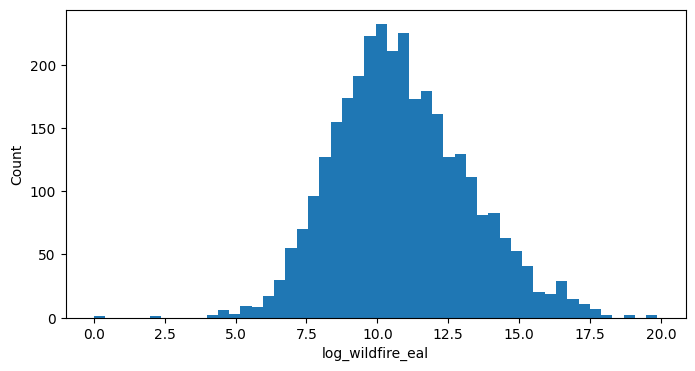

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(model_df_clean["log_wildfire_eal"].dropna(), bins=50)
plt.xlabel("log_wildfire_eal")
plt.ylabel("Count")
plt.show()


,Raw FEMA/NRI field,Model variable,Role in thesis,Reason for inclusion
0,POPULATION,population,Population exposure,Represents exposed population at county level
1,BUILDVALUE,building_value,Building exposure / asset value,Represents built-environment value exposed to wildfire risk
2,AGRIVALUE,agriculture_value,Agricultural exposure / asset value,Represents agricultural value exposed to wildfire risk
3,AREA,area_sq_mi,County spatial scale,Controls for county size and spatial scale
4,SOVI_SCORE,social_vulnerability_score,Social vulnerability,Captures social vulnerability component of risk
5,RESL_SCORE,community_resilience_score,Community resilience,Captures community capacity/resilience component of risk


Saved table PDF: /content/thesis_exports/notebook2_baseline_predictors_no_titles/table_1_selected_baseline_predictors.pdf


,Derived feature,Formula,Interpretation,Use in model
0,population_density,population / area_sq_mi,Population exposure intensity,Exposure intensity predictor
1,building_value_density,building_value / area_sq_mi,Built asset concentration per unit area,Economic exposure predictor
2,agriculture_value_density,agriculture_value / area_sq_mi,Agricultural asset concentration per unit area,Agricultural exposure predictor
3,building_value_per_capita,building_value / population,Approximate built asset value per resident,Normalized value/exposure predictor


Saved table PDF: /content/thesis_exports/notebook2_baseline_predictors_no_titles/table_2_derived_baseline_features.pdf


,Item,Value
0,Final non-leaky baseline modeling records,3144
1,Number of predictors excluding target and IDs,12
2,Target variable,wildfire_eal
3,Modeling target,log_wildfire_eal
4,Missing target rows after merge,0
5,Missing predictor values before imputation,0


Saved table PDF: /content/thesis_exports/notebook2_baseline_predictors_no_titles/table_3_final_baseline_dataset_summary.pdf


,Variable,Missing values,Missing percentage
0,state,0,0.0
1,county,0,0.0
2,county_fips,0,0.0
3,wildfire_eal,0,0.0
4,log_wildfire_eal,0,0.0
5,state_pred,0,0.0
6,county_pred,0,0.0
7,population,0,0.0
8,building_value,0,0.0
9,agriculture_value,0,0.0


Saved table PDF: /content/thesis_exports/notebook2_baseline_predictors_no_titles/table_4_final_baseline_missingness.pdf


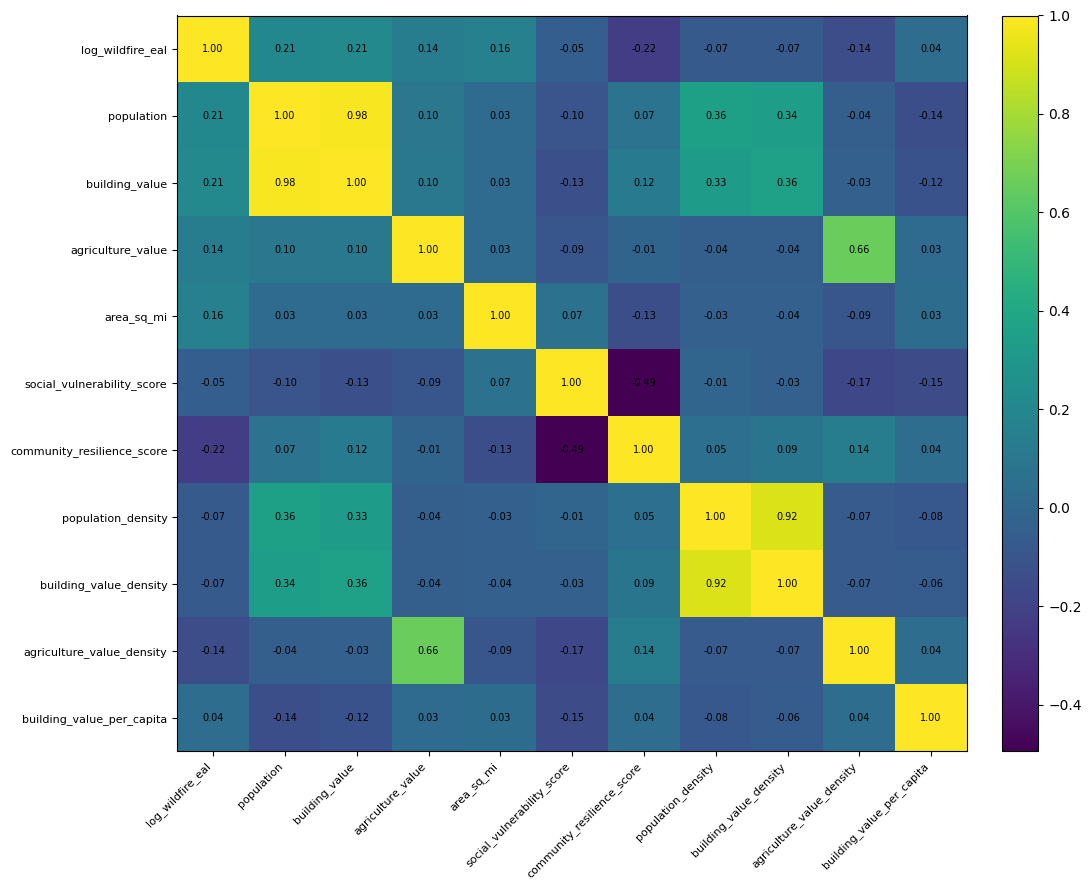

Saved figure PDF: /content/thesis_exports/notebook2_baseline_predictors_no_titles/figure_1_baseline_predictor_correlation_matrix.pdf
Saved figure PNG: /content/thesis_exports/notebook2_baseline_predictors_no_titles/figure_1_baseline_predictor_correlation_matrix.png


,state,county,county_fips,wildfire_eal,log_wildfire_eal,population,building_value,agriculture_value,area_sq_mi,social_vulnerability_score,community_resilience_score,population_density,building_value_density,agriculture_value_density,building_value_per_capita
0,Alabama,Autauga,01001,3.626224e+04,10.498560,58764,1.024141e+10,27630646.0,610.470508,38.040712,55.120865,96.260178,1.677625e+07,45261.229851,174280.275458
1,Alabama,Baldwin,01003,1.500314e+06,14.221186,231365,5.160230e+10,155012958.0,2047.738775,44.243003,93.002545,112.985603,2.519965e+07,75699.576484,223034.170078
2,Alabama,Barbour,01005,2.590932e+04,10.162397,25160,5.441822e+09,135914589.0,913.646511,96.374046,11.164122,27.538003,5.956157e+06,148760.584468,216288.651550
3,Alabama,Bibb,01007,3.260612e+04,10.392286,22239,3.532631e+09,5410008.0,632.486798,75.254453,22.169211,35.161208,5.585304e+06,8553.550871,158848.459103
4,Alabama,Blount,01009,9.336726e+04,11.444307,58992,8.773489e+09,312712010.0,657.196555,69.338422,15.648855,89.763100,1.334987e+07,475827.220591,148723.370271
5,Alabama,Bullock,01011,2.229438e+04,10.012135,10326,1.771889e+09,86549172.0,631.454512,97.550891,33.142494,16.352722,2.806044e+06,137063.193499,171594.899187
6,Alabama,Butler,01013,9.859778e+03,9.196320,19015,3.870967e+09,170002545.0,785.734461,91.762087,50.031807,24.200288,4.926559e+06,216361.319931,203574.402209
7,Alabama,Calhoun,01015,3.404425e+05,12.738005,116250,2.547253e+10,111764989.0,618.455143,81.488550,48.441476,187.968362,4.118735e+07,180716.403107,219118.524860
8,Alabama,Chambers,01017,3.777103e+04,10.539324,34738,6.728043e+09,11671106.0,609.202347,79.421120,41.444020,57.022105,1.104402e+07,19158.012194,193679.629426
9,Alabama,Cherokee,01019,1.069436e+05,11.580067,24933,4.977413e+09,195803233.0,606.033346,81.806616,16.125954,41.141300,8.213100e+06,323089.866619,199631.517507


Saved table PDF: /content/thesis_exports/notebook2_baseline_predictors_no_titles/table_5_final_baseline_dataset_sample.pdf


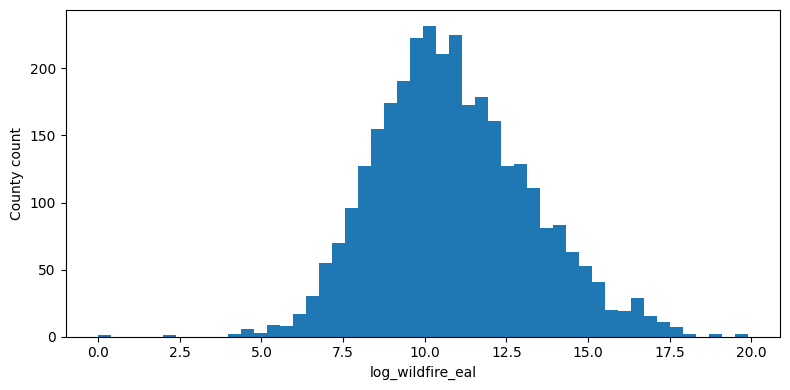

Saved figure PDF: /content/thesis_exports/notebook2_baseline_predictors_no_titles/figure_2_log_wildfire_eal_after_baseline_merge.pdf
Saved figure PNG: /content/thesis_exports/notebook2_baseline_predictors_no_titles/figure_2_log_wildfire_eal_after_baseline_merge.png


In [18]:
# ============================================================
# Export helper functions with no titles in exported tables/figures
# Updated table exporter: wrapped text, fixed column widths, no clipping
# ============================================================
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
!pip -q install reportlab

# ReportLab is used for clean PDF tables with wrapped text.
# This fixes text overflow in Table 1 and header collisions in Table 5.
from reportlab.lib import colors
from reportlab.lib.pagesizes import A4, A3, landscape
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, PageBreak
from reportlab.pdfbase.pdfmetrics import stringWidth


def _format_table_value(x):
    """Readable formatting for table cells."""
    if pd.isna(x):
        return ""
    if isinstance(x, (int, np.integer)):
        return f"{x:,}"
    if isinstance(x, (float, np.floating)):
        ax = abs(x)
        if ax >= 100000:
            return f"{x:,.0f}"
        if ax >= 1000:
            return f"{x:,.2f}"
        return f"{x:,.4f}"
    return str(x)


def _paragraphize(value, style):
    """Convert any value to a wrapped ReportLab Paragraph."""
    text = _format_table_value(value)
    text = text.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")
    text = text.replace("\n", "<br/>")
    return Paragraph(text, style)


def save_dataframe_as_pdf_no_title(
    df,
    path,
    rows_per_page=25,
    fontsize=7,
    page_size="A4_landscape",
    col_widths=None,
    header_aliases=None,
    repeat_rows=1,
):
    """
    Save a pandas DataFrame as a clean multi-page PDF table without a title.
    Uses ReportLab so text wraps inside cells instead of overflowing.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if page_size == "A3_landscape":
        pagesize = landscape(A3)
    elif page_size == "A3_portrait":
        pagesize = A3
    elif page_size == "A4_portrait":
        pagesize = A4
    else:
        pagesize = landscape(A4)

    doc = SimpleDocTemplate(
        str(path),
        pagesize=pagesize,
        leftMargin=0.35 * inch,
        rightMargin=0.35 * inch,
        topMargin=0.35 * inch,
        bottomMargin=0.35 * inch,
    )

    styles = getSampleStyleSheet()
    body_style = ParagraphStyle(
        "table_body_wrap",
        parent=styles["Normal"],
        fontName="Helvetica",
        fontSize=fontsize,
        leading=fontsize + 2,
        alignment=1,   # center
        wordWrap="CJK",
    )
    header_style = ParagraphStyle(
        "table_header_wrap",
        parent=styles["Normal"],
        fontName="Helvetica-Bold",
        fontSize=fontsize,
        leading=fontsize + 2,
        alignment=1,
        wordWrap="CJK",
    )

    # Display-only header aliases to avoid header collision in wide tables.
    columns = list(df.columns)
    if header_aliases is None:
        header_aliases = {}
    display_headers = [header_aliases.get(c, c) for c in columns]

    # Convert table content to wrapped paragraphs.
    df_to_save = df.copy()
    story = []

    for start in range(0, len(df_to_save), rows_per_page):
        page_df = df_to_save.iloc[start:start + rows_per_page]
        data = [[_paragraphize(h, header_style) for h in display_headers]]
        for _, row in page_df.iterrows():
            data.append([_paragraphize(row[c], body_style) for c in columns])

        # If widths are not provided, distribute evenly across available width.
        available_width = pagesize[0] - doc.leftMargin - doc.rightMargin
        if col_widths is None:
            widths = [available_width / len(columns)] * len(columns)
        else:
            # Accept relative widths; normalize to available width.
            total = sum(col_widths)
            widths = [available_width * w / total for w in col_widths]

        table = Table(data, colWidths=widths, repeatRows=repeat_rows, hAlign="CENTER")
        table.setStyle(TableStyle([
            ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#EDEDED")),
            ("TEXTCOLOR", (0, 0), (-1, 0), colors.black),
            ("GRID", (0, 0), (-1, -1), 0.35, colors.HexColor("#666666")),
            ("BOX", (0, 0), (-1, -1), 0.6, colors.HexColor("#333333")),
            ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
            ("ALIGN", (0, 0), (-1, -1), "CENTER"),
            ("LEFTPADDING", (0, 0), (-1, -1), 4),
            ("RIGHTPADDING", (0, 0), (-1, -1), 4),
            ("TOPPADDING", (0, 0), (-1, -1), 5),
            ("BOTTOMPADDING", (0, 0), (-1, -1), 5),
        ]))
        story.append(table)
        if start + rows_per_page < len(df_to_save):
            story.append(PageBreak())

    doc.build(story)
    print(f"Saved table PDF: {path}")
    return path


# ============================================================
# Notebook 2 exports: baseline county-level predictors
# No titles are added to exported tables or figures.
# ============================================================
EXPORT_DIR = Path("/content/thesis_exports/notebook2_baseline_predictors_no_titles")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

baseline_predictor_description = pd.DataFrame({
    "Raw FEMA/NRI field": ["POPULATION", "BUILDVALUE", "AGRIVALUE", "AREA", "SOVI_SCORE", "RESL_SCORE"],
    "Model variable": ["population", "building_value", "agriculture_value", "area_sq_mi", "social_vulnerability_score", "community_resilience_score"],
    "Role in thesis": ["Population exposure", "Building exposure / asset value", "Agricultural exposure / asset value", "County spatial scale", "Social vulnerability", "Community resilience"],
    "Reason for inclusion": ["Represents exposed population at county level", "Represents built-environment value exposed to wildfire risk", "Represents agricultural value exposed to wildfire risk", "Controls for county size and spatial scale", "Captures social vulnerability component of risk", "Captures community capacity/resilience component of risk"]
})
display(baseline_predictor_description)
save_dataframe_as_pdf_no_title(
    baseline_predictor_description,
    EXPORT_DIR / "table_1_selected_baseline_predictors.pdf",
    rows_per_page=20,
    fontsize=8,
    page_size="A4_landscape",
    col_widths=[1.2, 1.5, 1.9, 4.4],
    header_aliases={
        "Raw FEMA/NRI field": "Raw FEMA/NRI\nfield",
        "Model variable": "Model\nvariable",
        "Role in thesis": "Role in\nthesis",
        "Reason for inclusion": "Reason for\ninclusion",
    },
)

derived_feature_description = pd.DataFrame({
    "Derived feature": ["population_density", "building_value_density", "agriculture_value_density", "building_value_per_capita"],
    "Formula": ["population / area_sq_mi", "building_value / area_sq_mi", "agriculture_value / area_sq_mi", "building_value / population"],
    "Interpretation": ["Population exposure intensity", "Built asset concentration per unit area", "Agricultural asset concentration per unit area", "Approximate built asset value per resident"],
    "Use in model": ["Exposure intensity predictor", "Economic exposure predictor", "Agricultural exposure predictor", "Normalized value/exposure predictor"]
})
display(derived_feature_description)
save_dataframe_as_pdf_no_title(
    derived_feature_description,
    EXPORT_DIR / "table_2_derived_baseline_features.pdf",
    rows_per_page=20,
    fontsize=8,
    page_size="A4_landscape",
    col_widths=[1.8, 2.2, 3.0, 2.3],
    header_aliases={
        "Derived feature": "Derived<br/>feature",
        "Use in model": "Use in<br/>model",
    },
)

id_cols = ["state", "county", "county_fips"]
target_cols = ["wildfire_eal", "log_wildfire_eal"]
predictor_cols = [c for c in model_df_clean.columns if c not in id_cols + target_cols]

baseline_summary = pd.DataFrame({
    "Item": [
        "Final non-leaky baseline modeling records",
        "Number of predictors excluding target and IDs",
        "Target variable",
        "Modeling target",
        "Missing target rows after merge",
        "Missing predictor values before imputation"
    ],
    "Value": [
        model_df_clean.shape[0],
        len(predictor_cols),
        "wildfire_eal",
        "log_wildfire_eal",
        model_df_clean["wildfire_eal"].isna().sum(),
        model_df_clean[predictor_cols].isna().sum().sum()
    ]
})
display(baseline_summary)
save_dataframe_as_pdf_no_title(
    baseline_summary,
    EXPORT_DIR / "table_3_final_baseline_dataset_summary.pdf",
    rows_per_page=20,
    fontsize=9,
    page_size="A4_landscape",
    col_widths=[3.2, 2.0],
)

baseline_missingness = model_df_clean.isna().sum().reset_index()
baseline_missingness.columns = ["Variable", "Missing values"]
baseline_missingness["Missing percentage"] = (baseline_missingness["Missing values"] / len(model_df_clean) * 100).round(3)
display(baseline_missingness)
save_dataframe_as_pdf_no_title(
    baseline_missingness,
    EXPORT_DIR / "table_4_final_baseline_missingness.pdf",
    rows_per_page=30,
    fontsize=8,
    page_size="A4_landscape",
    col_widths=[3.0, 1.4, 1.6],
    header_aliases={"Missing values": "Missing<br/>values", "Missing percentage": "Missing<br/>percentage"},
)

corr_cols = [
    "log_wildfire_eal", "population", "building_value", "agriculture_value", "area_sq_mi",
    "social_vulnerability_score", "community_resilience_score", "population_density",
    "building_value_density", "agriculture_value_density", "building_value_per_capita"
]
corr_cols = [c for c in corr_cols if c in model_df_clean.columns]
corr = model_df_clean[corr_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, aspect="auto")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.tight_layout()
fig_path_pdf = EXPORT_DIR / "figure_1_baseline_predictor_correlation_matrix.pdf"
fig_path_png = EXPORT_DIR / "figure_1_baseline_predictor_correlation_matrix.png"
plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.show()
print("Saved figure PDF:", fig_path_pdf)
print("Saved figure PNG:", fig_path_png)

sample_cols = [
    "state", "county", "county_fips", "wildfire_eal", "log_wildfire_eal",
    "population", "building_value", "agriculture_value", "area_sq_mi",
    "social_vulnerability_score", "community_resilience_score",
    "population_density", "building_value_density", "agriculture_value_density", "building_value_per_capita"
]
sample_cols = [c for c in sample_cols if c in model_df_clean.columns]
baseline_sample = model_df_clean[sample_cols].head(20).copy()
display(baseline_sample)

# Display-only header names with line breaks to prevent collision in Table 5.
table5_header_aliases = {
    "state": "State",
    "county": "County",
    "county_fips": "County\nFIPS",
    "wildfire_eal": "Wildfire\nEAL",
    "log_wildfire_eal": "Log\nwildfire\nEAL",
    "population": "Population",
    "building_value": "Building\nvalue",
    "agriculture_value": "Agriculture\nvalue",
    "area_sq_mi": "Area\n(sq mi)",
    "social_vulnerability_score": "Social\nvulnerability\nscore",
    "community_resilience_score": "Community\nresilience\nscore",
    "population_density": "Population\ndensity",
    "building_value_density": "Building\nvalue\ndensity",
    "agriculture_value_density": "Agriculture\nvalue\ndensity",
    "building_value_per_capita": "Building\nvalue\nper capita",
}

save_dataframe_as_pdf_no_title(
    baseline_sample,
    EXPORT_DIR / "table_5_final_baseline_dataset_sample.pdf",
    rows_per_page=20,
    fontsize=5.8,
    page_size="A3_landscape",
    col_widths=[1.0, 1.2, 0.85, 1.15, 0.9, 1.0, 1.2, 1.2, 0.8, 1.1, 1.1, 1.0, 1.2, 1.2, 1.15],
    header_aliases=table5_header_aliases,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(model_df_clean["log_wildfire_eal"].dropna(), bins=50)
ax.set_xlabel("log_wildfire_eal")
ax.set_ylabel("County count")
plt.tight_layout()
fig_path_pdf = EXPORT_DIR / "figure_2_log_wildfire_eal_after_baseline_merge.pdf"
fig_path_png = EXPORT_DIR / "figure_2_log_wildfire_eal_after_baseline_merge.png"
plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.show()
print("Saved figure PDF:", fig_path_pdf)
print("Saved figure PNG:", fig_path_png)
